<a href="https://colab.research.google.com/github/ltd03112007-lab/BTVN/blob/main/2_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 20.6 MB/s eta 0:00:00


mức giảm giá cho đồng hồ xa xỉ thủ công là:14.50%


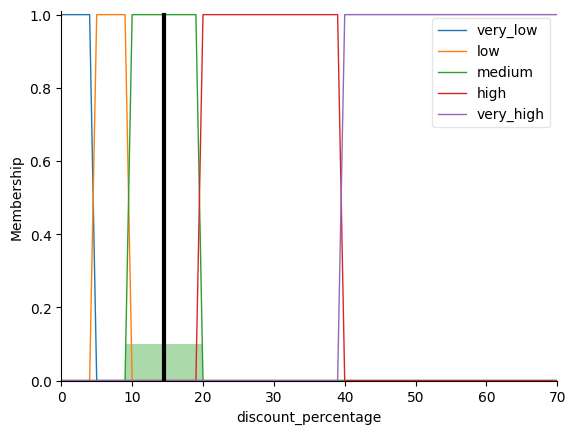

In [10]:
import skfuzzy as fuzz
import numpy as np
from skfuzzy import control as ctrl

demand=ctrl.Antecedent(np.arange(0,101,1),'demand')
demand['low']=fuzz.trimf(demand.universe,[0,0,50])
demand['medium']=fuzz.trimf(demand.universe,[0,50,100])
demand['high']=fuzz.trimf(demand.universe,[50,100,100])

competitor=ctrl.Antecedent(np.arange(0,101,1),'competitor')
competitor['low']=fuzz.trimf(competitor.universe,[0,0,50])
competitor['medium']=fuzz.trimf(competitor.universe,[0,50,100])
competitor['high']=fuzz.trimf(competitor.universe,[50,100,100])

store_reputation=ctrl.Antecedent(np.arange(0,101,1),'store_reputation')
store_reputation['low']=fuzz.trimf(store_reputation.universe,[0,0,50])
store_reputation['medium']=fuzz.trimf(store_reputation.universe,[0,50,100])
store_reputation['high']=fuzz.trimf(store_reputation.universe,[50,100,100])

profit_margin=ctrl.Antecedent(np.arange(0,101,1),'profit_margin')
profit_margin['low']=fuzz.trimf(profit_margin.universe,[0,0,50])
profit_margin['medium']=fuzz.trimf(profit_margin.universe,[0,50,100])
profit_margin['high']=fuzz.trimf(profit_margin.universe,[50,100,100])

seasonal_demand=ctrl.Antecedent(np.arange(0,101,1),'seasonal_demand')
seasonal_demand['none']=fuzz.trimf(seasonal_demand.universe,[0,0,50])
seasonal_demand['moderate']=fuzz.trimf(seasonal_demand.universe,[0,50,100])
seasonal_demand['high']=fuzz.trimf(seasonal_demand.universe,[50,100,100])

discount_percentage=ctrl.Consequent(np.arange(0,71,1),'discount_percentage')
discount_percentage['very_low']=fuzz.trapmf(discount_percentage.universe,[0,0,4,5])
discount_percentage['low']=fuzz.trapmf(discount_percentage.universe,[4,5,9,10])
discount_percentage['medium']=fuzz.trapmf(discount_percentage.universe,[9,10,19,20])
discount_percentage['high']=fuzz.trapmf(discount_percentage.universe,[19,20,39,40])
discount_percentage['very_high']=fuzz.trapmf(discount_percentage.universe,[39,40,70,70])

rule1 = ctrl.Rule(demand['high'] & competitor['low'] & profit_margin['low'], discount_percentage['very_low'])
rule2 = ctrl.Rule(demand['low'] & competitor['high'] & profit_margin['high'], discount_percentage['high'])
rule3 = ctrl.Rule(store_reputation['high'] & profit_margin['medium'] & seasonal_demand['high'], discount_percentage['medium'])
rule4 = ctrl.Rule(competitor['high'] & seasonal_demand['high'] & profit_margin['high'], discount_percentage['very_high'])
rule5 = ctrl.Rule(store_reputation['low'] &demand['medium'] & profit_margin['low'], discount_percentage['medium'])
rule6 = ctrl.Rule(demand['high'] &seasonal_demand['none'] & competitor['low'], discount_percentage['very_low'])
rule7 = ctrl.Rule(profit_margin['high'] &competitor['medium'] & seasonal_demand['moderate'], discount_percentage['medium'])

control_system=ctrl.ControlSystem([rule1,rule2,rule3,rule4,rule5,rule6,rule7])
discount_system=ctrl.ControlSystemSimulation(control_system)
discount_system.input['demand'] = 90
discount_system.input['competitor'] = 50
discount_system.input['store_reputation'] = 4.2
discount_system.input['profit_margin'] = 85
discount_system.input['seasonal_demand'] = 95
discount_system.compute()
print(f'mức giảm giá cho đồng hồ xa xỉ thủ công là:{discount_system.output['discount_percentage']:.2f}%')
discount_percentage.view(sim=discount_system)